# Assignment 3

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np # For working with multidimensional array and matrix data structures.
import matplotlib.pyplot as plt # Used for ploting graphs.

# Do it yourself

You will be asked to implement K-means and GMM yourself in this section.

## Generate Random Data

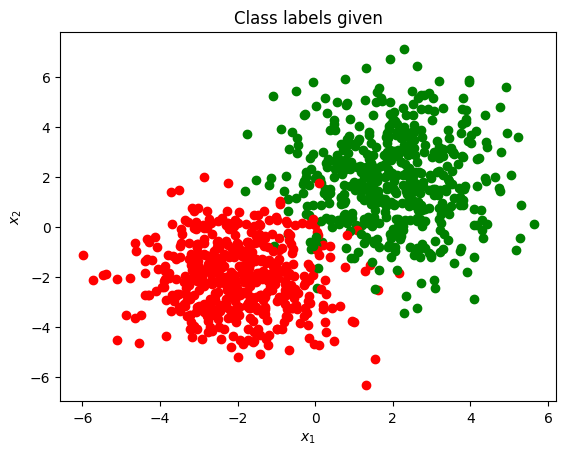

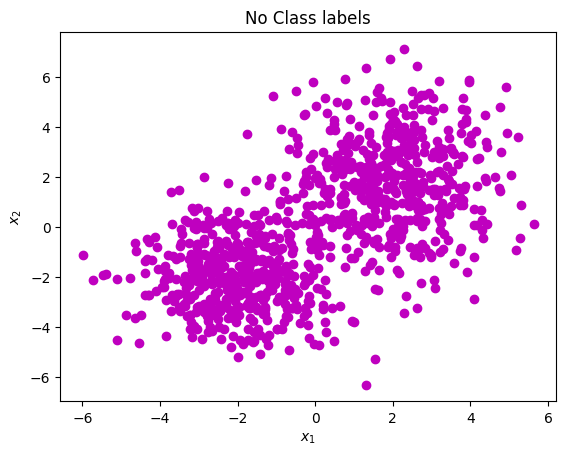

In [3]:
# Training data - two randomly-generated Gaussian-distributed clouds of points in 2d space
np.random.seed(0)
# Number of points
N = 1000
# Labels for each cluster
y = np.random.randint(low=0, high=2, size = N)
c = np.array(["r","g"])
# Mean of each cluster
means = np.array([[-2, 2], [-2, 2],])
# Covariance (in X and Y direction) of each cluster
covariances = np.random.random_sample((2, 2)) + 1
# Dimensions of each point
X = np.vstack([np.random.randn(N)*covariances[0, y] + means[0, y],
               np.random.randn(N)*covariances[1, y] + means[1, y]])

for k in range(X.shape[1]):
    plt.plot(X[0,k],X[1,k],c[y[k]]+"o")
    
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Class labels given")
plt.show()

for k in range(X.shape[1]):
    plt.plot(X[0,k],X[1,k],"m"+"o")
    
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("No Class labels")
plt.show()

# Plot the data


## K-means

**Please write a generic python function (in a separate package) which implements a generic version of the K-means algorithm. Your function should take as input a $d$-dimensional data set and the number of clusters into which you wish to group your data set. Return the means of your K-clusters and the assigned labels of your dataset (use 1-of-K coding to represent your labels). Initialize your means with two random samples.**

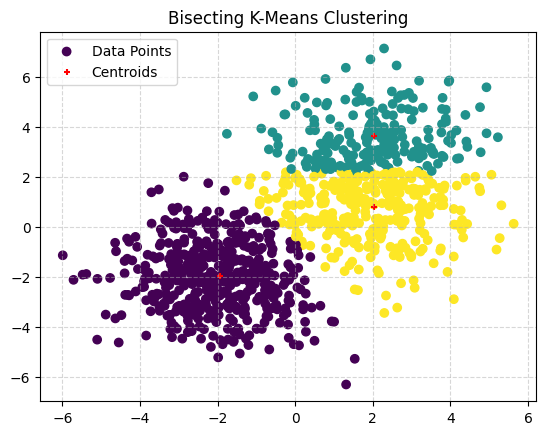

In [4]:
from Joe_kmeans import *
X = X.T
final_centroids = kmeans(X, 3)
final_labels = assign_labels(X, final_centroids)

plt.scatter(X[:, 0], X[:, 1], c=final_labels, cmap='viridis', marker='o', label='Data Points')
plt.scatter(final_centroids[:, 0], final_centroids[:, 1], c='red', marker='+', s=20, label='Centroids')
plt.title("Bisecting K-Means Clustering")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [5]:
from IPython.display import HTML
from IPython.display import display
from IPython.display import Image

**Use your newly created function to assign labels to the random dataset we generated above. Plot the data and their newly assigned labels. Also plot the mean of the two clusters. Your generated plot should resemble the following:**

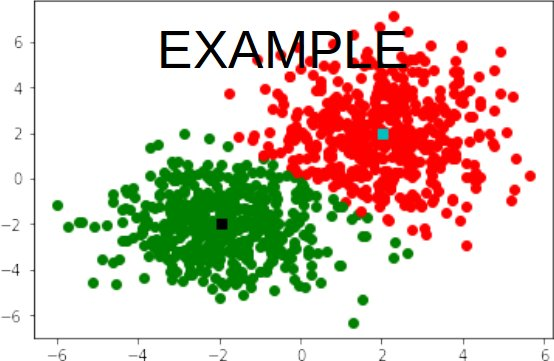

In [6]:
display(Image(filename='./kmeans.jpg'))

$x_1$ is on the $x$-axis and $x_2$ is on the $y$-axis.

# Perform K-means on an image

In [7]:
from skimage import io  # for loading an image from a file.
from sklearn.datasets import load_sample_image # imports available image from sklean dataset

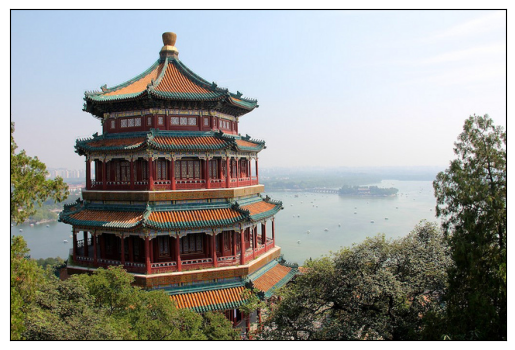

In [8]:
china = load_sample_image("china.jpg")
ax = plt.axes(xticks=[], yticks=[])
ax.imshow(china);

In [9]:
# Reshape the image

In [10]:
data = china / 255.0 # use 0...1 scale
data = data.reshape(427 * 640, 3)
data.shape

(273280, 3)

# Visualise possible colors from the image, using a k-means clustering across the pixel space


In [11]:
def plot_pixels(data, title, colors=None, N=10000):
    if colors is None:
        colors = data
    
    # choose a random subset
    rng = np.random.RandomState(0)
    i = rng.permutation(data.shape[0])[:N]
    colors = colors[i]
    R, G, B = data[i].T
    
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    ax[0].scatter(R, G, color=colors, marker='.')
    ax[0].set(xlabel='Red', ylabel='Green', xlim=(0, 1), ylim=(0, 1))

    ax[1].scatter(R, B, color=colors, marker='.')
    ax[1].set(xlabel='Red', ylabel='Blue', xlim=(0, 1), ylim=(0, 1))

    fig.suptitle(title, size=20);

 The  MiniBatchKmeans is a variant of the KMeans algorithm which uses mini-batches to reduce the computation time, 
instead of using the full dataset at each iteration while still attempting to optimize the same objective function. 
 Mini-batches are subsets of the input data, randomly sampled in each training iteration. 
This increases the speed of the algorithm by a factor of 3–4 typically. Especially important, it makes it possible to cluster huge datasets that do not fit in memory.

Color Quantization is the process of reducing the number of colors in an image while keeping the visual appearance of the image intact. 
This is a useful image compression technique that is quite useful for devices that can show a limited number of colors due to memory restriction.

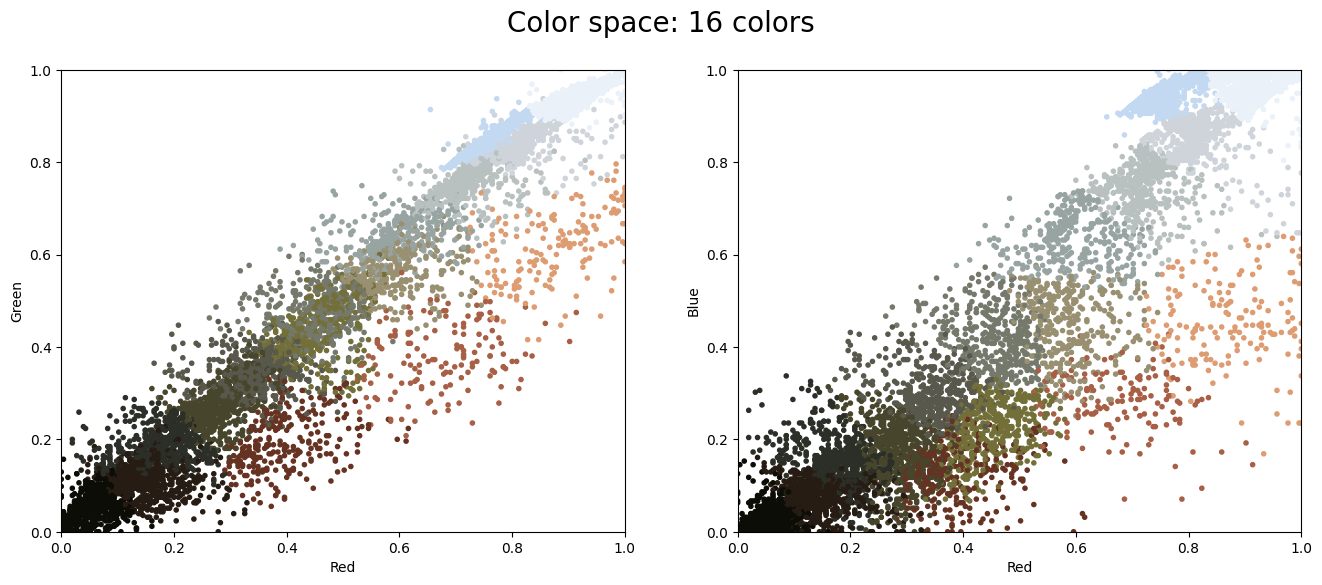

In [12]:
from sklearn.cluster import MiniBatchKMeans
kmeans = MiniBatchKMeans(16)
kmeans.fit(data)
new_colors = kmeans.cluster_centers_[kmeans.predict(data)]

plot_pixels(data, colors=new_colors,
            title="Color space: 16 colors")

In [13]:
from ipywidgets import interact, interactive, fixed, interact_manual, IntSlider # for interactive slider

**Please create a widget function using the ipywidgets library of python that is already imported above and appy it to the image (china) above. Your function should take input K (the number of clusters) range slider. Hint: Read the documentation on ipywidgets. Reproducing the image using only 3 colors gives something like the following image.** 

**How many clusters do you need for a perfect reproduction?**

In [14]:
def update_image(k):
    # Fit KMeans to the scaled data and map the new colors
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, n_init="auto").fit(data)
    recolored_image = kmeans.cluster_centers_[kmeans.predict(data)].reshape(china.shape)
    
    # Plot the reproduced image
    plt.figure(figsize=(10, 6))
    plt.imshow(recolored_image)
    plt.title(f"Image Reproduction: {k} Colors", size=16)
    plt.axis('off')
    plt.show()

# Deploy the interactive slider linked to the function
interact(update_image, k=IntSlider(min=1, max=64, step=1, value=16, description='Clusters (K):', continuous_update=False))

interactive(children=(IntSlider(value=16, continuous_update=False, description='Clusters (K):', max=64, min=1)…

<function __main__.update_image(k)>

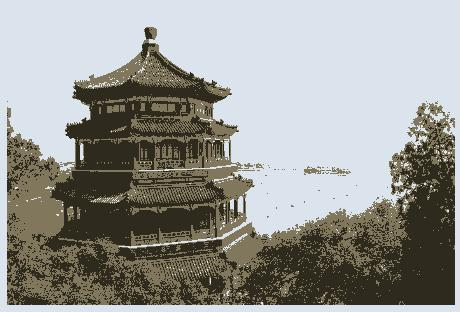

In [15]:
display(Image(filename='./Compressed.jpg'))

## GMM

**Please write a generic python function (in a separate package) which implements a generic version of the Gaussian Mixture Models algorithm. Your function should take as input a $d$-dimensional data set and the number of clusters into which you wish to group your data set. Return the number of members, the means and covariances of your K-clusters. Also return the responsibilites(Gamma) of your observations (of every sample in your dataset). Use your K-means function to intialize your GMM.**

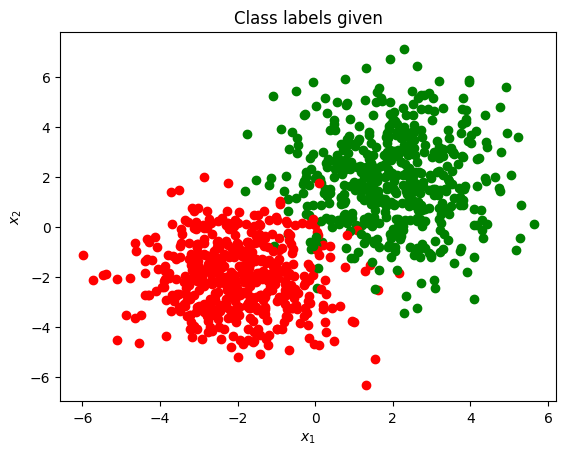

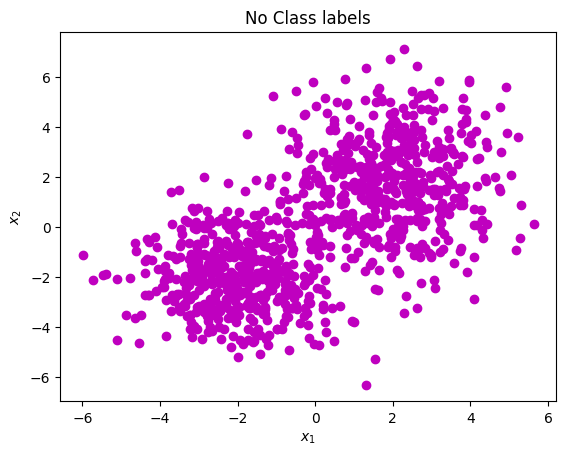

In [16]:
# Training data - two randomly-generated Gaussian-distributed clouds of points in 2d space
np.random.seed(0)
# Number of points
N = 1000
# Labels for each cluster
y = np.random.randint(low=0, high=2, size = N)
c = np.array(["r","g"])
# Mean of each cluster
means = np.array([[-2, 2], [-2, 2],])
# Covariance (in X and Y direction) of each cluster
covariances = np.random.random_sample((2, 2)) + 1
# Dimensions of each point
X = np.vstack([np.random.randn(N)*covariances[0, y] + means[0, y],
               np.random.randn(N)*covariances[1, y] + means[1, y]])

for k in range(X.shape[1]):
    plt.plot(X[0,k],X[1,k],c[y[k]]+"o")
    
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Class labels given")
plt.show()

for k in range(X.shape[1]):
    plt.plot(X[0,k],X[1,k],"m"+"o")
    
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("No Class labels")
plt.show()

# Plot the data

X = X.T

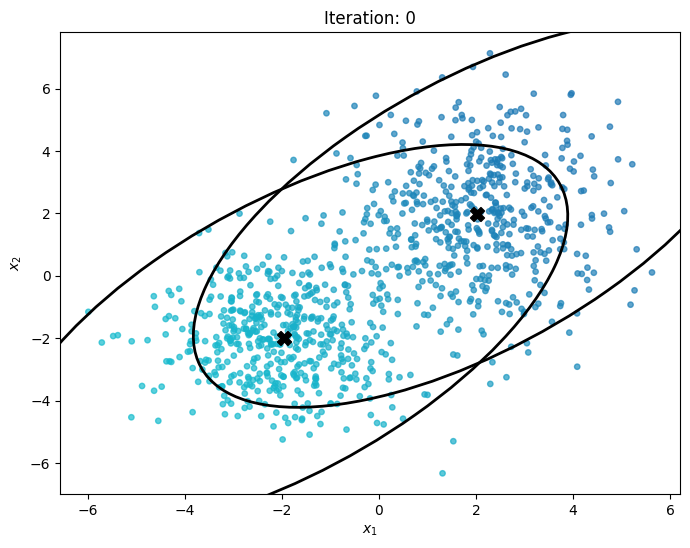

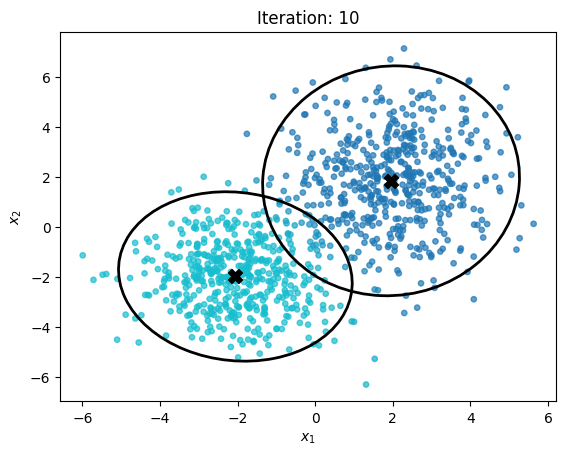

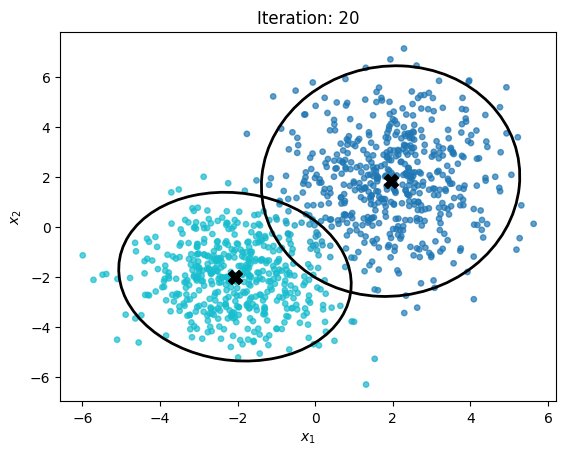

Converged at iteration 20


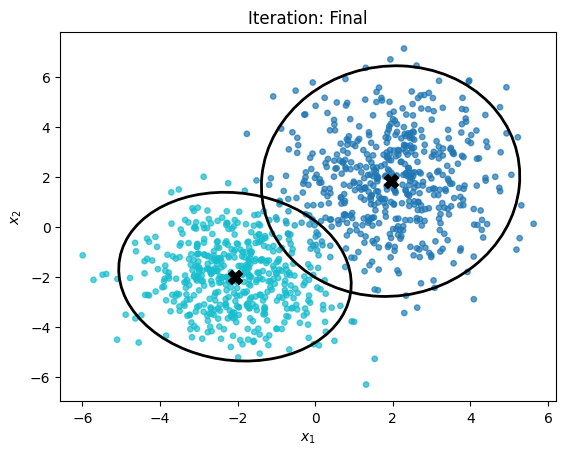

Priors(Weights): [0.51574428 0.48425379]
Means: [[ 1.94250918  1.82149477]
 [-2.06773999 -2.0023735 ]]
Covariance: [[[ 1.84977203  0.10881803]
  [ 0.10881803  3.5549474 ]]

 [[ 1.49783945 -0.14894993]
  [-0.14894993  1.90319046]]]
Responsibility: [[1.73062869e-02 9.82693407e-01]
 [9.99449093e-01 5.50567684e-04]
 [9.99926267e-01 7.33943151e-05]
 ...
 [1.07232666e-03 9.98927443e-01]
 [9.99299663e-01 6.99983332e-04]
 [1.55555721e-01 8.44443639e-01]]


In [25]:
from Joe_GMM import *
p, u, s, gamma_var = fit_gmm(X,2, plot_interval= 10)
print("Priors(Weights):", p)
print("Means:", u)
print("Covariance:", s)
print("Responsibility:", gamma_var)

**Use your newly created function to cluster the generated data set at the start of the K-Means section. Plot the 95% confidence
interval of your data and use the responsibility of each data point to set the color of each sample.
Your generated plot should resemble the following:**

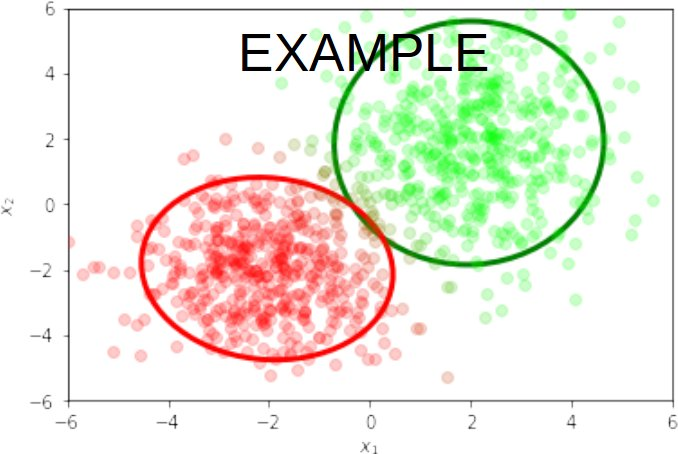

In [18]:
display(Image(filename='./gmm.jpg'))

# Clustering of digits data using GMM

For the next problem you will use GMM (scikit-learn version) to cluster the digits data in the scikit-learn library. 

## Load the digit datasets

The datasets are loaded into a dictionary.

In [19]:
# Import `datasets` from `sklearn`
from sklearn import datasets

# Load in the `digits` data
digits = datasets.load_digits()
print(digits.keys())

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])


In [20]:
# Find the number of unique labels
number_digits = len(np.unique(digits.target))

print (number_digits)

10


## Inspect the different digit  images

In [21]:
import matplotlib.cm as cm # helps you work with grayscale images

In [22]:
def show_digits(k=0):
    """
    Show the digits in the training set
    """
    
    plt.imshow(digits.images[k], cmap=cm.binary)   
    
    plt.show()
    
w_show_digits = interact(show_digits, k =(0, 1796)) 


interactive(children=(IntSlider(value=0, description='k', max=1796), Output()), _dom_classes=('widget-interact…


**Next, fit the data to a 10 component GMM model, using the scikit-learn package.**

**Once you have built the GMM model, extract the means as well as the covariances of the 10 GMM components. Display the means to get something like the  image below.**

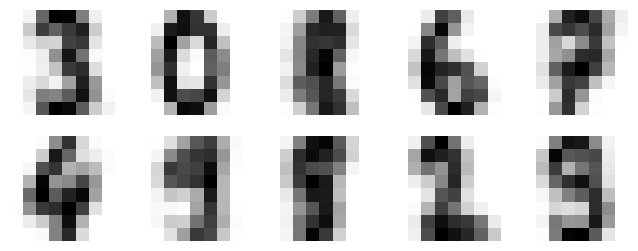

In [23]:
data = digits.data

np.random.seed(1)
# Insert GMM code
from sklearn.mixture  import GaussianMixture
from sklearn.metrics import confusion_matrix
gmm = GaussianMixture(n_components = 10)
gmm.fit(data)

pred = gmm.predict(data)
means = gmm.means_
covar = gmm.covariances_

fig, axes = plt.subplots(2, 5, figsize=(8, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(means[i].reshape(8, 8), cmap='binary')
    ax.axis('off')
plt.show()


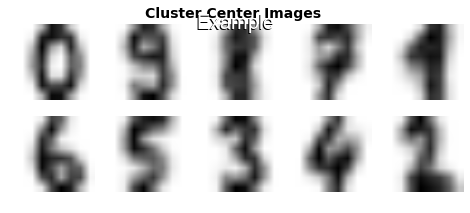

In [24]:
display(Image(filename='./wm_GMM.png'))

## Generate samples

**Use the means and covariances of the different components and draw a sample from each component. Display the samples in an image.**

*Hint*: Read the documentation of scipy.stats.multivariate_normal

**Now can you try out the color quantization and digit analyses with your newly created implementations of k-means and GMM respectively and see if you get the same outputs.**

# Parameter Complexity: Gaussian Mixture Models vs. K-Means

When selecting a clustering algorithm, understanding the number of parameters the model needs to estimate is crucial. The parameter count dictates the model's flexibility, its computational cost, and its susceptibility to overfitting (especially in high-dimensional spaces).

Let:
* K = Number of clusters (components)
* D = Number of features (dimensions)

Below is a detailed breakdown of the parameters estimated by Gaussian Mixture Models (GMMs) and K-Means.

---

## 1. Gaussian Mixture Models (GMM)

A GMM estimates three types of parameters for each cluster:
1. Weights (Priors): The probability that a random data point belongs to a specific cluster.
2. Means: The center of the cluster.
3. Covariance: The shape, size, and orientation of the cluster.

The complexity of a GMM is heavily determined by the type of covariance matrix used.

### A. Full Covariance Matrix
A full covariance model captures the correlation between all features, allowing clusters to take on any elliptical shape and orientation.

* Total Parameters: (K - 1) + KD + K * (D(D + 1) / 2)
* Breakdown:
  * Weights: K - 1 (There are K weights, but they must sum to 1).
  * Means: KD (A D-dimensional vector for each of the K clusters).
  * Covariances: K * (D(D + 1) / 2) (A full D x D covariance matrix is symmetric, requiring (D(D+1)/2) unique elements per cluster).
* Scaling: O(D^2). Highly flexible but prone to overfitting if D is large and the dataset is small.

### B. Diagonal Covariance Matrix
A diagonal covariance model assumes that features are independent within each cluster. Clusters can be elliptical but must be axis-aligned (no rotation).

* Total Parameters: (K - 1) + 2KD
* Breakdown:
  * Weights: K - 1
  * Means: KD
  * Covariances: KD (Only the D variance values along the diagonal are estimated per cluster).
* Scaling: O(D). Much more robust in high-dimensional spaces compared to a full covariance model, though it sacrifices the ability to model feature correlations.

---

## 2. K-Means Clustering

K-Means is a "hard-assignment" algorithm. It does not model cluster shapes, densities, or underlying probabilities. It solely focuses on finding the geometric center of the data partitions.

* Total Parameters: KD
* Breakdown:
  * Means (Centroids): KD (A D-dimensional vector for each of the K clusters).
* Why so few? K-Means does not estimate weights (priors) or covariance. Mathematically, it operates under the implicit assumption that all clusters have equal priors and identical, perfectly spherical (isotropic) covariances.

---

## Summary Comparison Table

| Model Type | Covariance Structure | Total Parameters Formula | Growth with Dimensions (D) |
| :--- | :--- | :--- | :--- |
| GMM (Full) | Elliptical, correlated | (K - 1) + KD + K * (D(D + 1) / 2) | Quadratic (O(D^2)) |
| GMM (Diag) | Elliptical, axis-aligned | (K - 1) + 2KD | Linear (O(D)) |
| K-Means | Spherical (Implicit) | KD | Linear (O(D)) |